In [461]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [462]:
id_list = [925, 165, 9, 477, 291, 162] #InfraRed = 925, concrete = 165, Auto MPG = 9, 
        #Real estate valuation = 477, Air-foil self-noise = 291, forest fires = 162

In [463]:
nr_of_seeds = 30 #nr of seeds in the experiments
index = 291

In [464]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [465]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse']]
    return topk_d, topk_df

In [466]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_10472\1884792786.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_10472\1884792786.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_10472\1884792786.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

<Axes: xlabel='method', ylabel='rmse'>

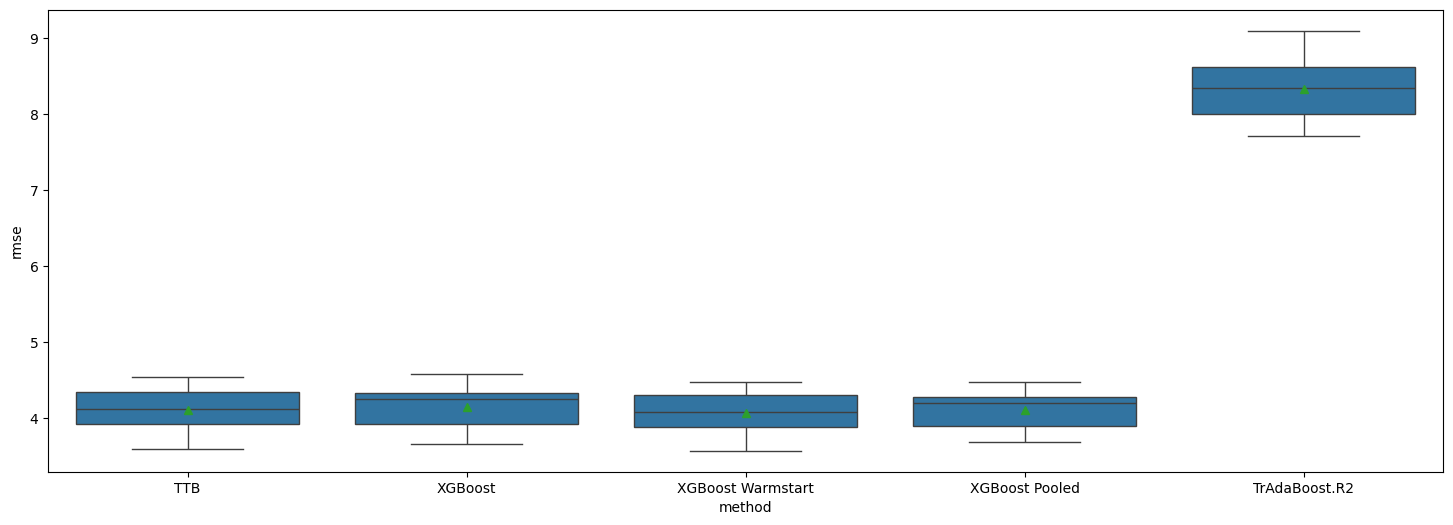

In [467]:
plt.figure(figsize = (18,6))
#Boxplot
dat = pd.read_csv(f'results/ttb_LS_{index}.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
#dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb_{index}.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'


data = pd.read_csv(f'results/xgb_warmstart_{index}.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart, best_XGBoost_params_warmstart = topk_per_d_per_method(
    xgboost_data_warmstart,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results/xgb_naive_{index}.csv')
xgboost_data_pooled = data
xgboost_data_pooled['method'] = 'XGBoost Pooled'

best_XGBoost_pooled, best_XGBoost_params_pooled = topk_per_d_per_method(
    xgboost_data_pooled,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_pooled['method'] = 'XGBoost Pooled'

data = pd.read_csv(f'results/trada_{index}.csv')
trada_data = data
trada_data['method'] = 'TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators', 'tree_size'], k=nr_of_seeds
)
best_trada['method'] = 'TrAdaBoost.R2'



df = best_LSTransferTreeBoost
#df = best_XGBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
df = pd.concat([df, best_XGBoost_pooled])
df = pd.concat([df, best_trada])

marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [468]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
1131,0.2,2.0,2.0,0.01,0.9,4.105956,30,875.0,400.0,4.006826,3.404435,3.951845,3.186202,TransferTreeBoost


In [469]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
76,0.125,2.0,4.139055,30,22,860.0,3.980712,3.172673,4.173243,3.446842,XGBoost


In [470]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
78,0.05,2.0,4.069734,30,78,861.0,3.817983,2.928379,3.959425,3.256679,XGBoost Warmstart


In [471]:
#Get best params in order
best_XGBoost_params_pooled.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,subsample,val_rmse,val_mae,rmse,mae,method
14,0.125,4.0,4.107632,30,24,860.0,1.0,3.934571,3.107256,4.239703,3.44842,XGBoost Pooled


In [472]:
best_trada_params.iloc[::nr_of_seeds]

,lr,n_estimators,tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,rmse,mae,method
10,0.1,10.0,3.0,8.321793,30,2,860.0,8.860049,7.751527,TrAdaBoost.R2


In [473]:
#Get best params in order
import numpy as np
print(
    np.round(best_LSTransferTreeBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_LSTransferTreeBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params_warmstart['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_warmstart['rmse']), 3), "&",
    np.round(best_XGBoost_params_pooled['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_pooled['rmse']), 3), "&",
    np.round(best_trada_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_trada_params['rmse']), 3)
)

4.106 & 0.259 & 4.139 & 0.254 & 4.07 & 0.281 & 4.108 & 0.234 & 8.322 & 0.406


In [474]:
#Print best hyperparameters for TransferTreeBoost
print(float(best_LSTransferTreeBoost_params.iloc[0]['v']), "&",
      float(best_LSTransferTreeBoost_params.iloc[0]['target_tree_size']), "&",
      float(best_LSTransferTreeBoost_params.iloc[0]['source_tree_size']), "&",
      float(best_LSTransferTreeBoost_params.iloc[0]['m_0']), "&",
      float(best_LSTransferTreeBoost_params.iloc[0]['k']))

0.2 & 2.0 & 2.0 & 0.9 & 0.01


In [475]:
data = pd.read_csv(f'results/ResNet_finetuned3_{index}.csv')
MLP_data = data
MLP_data['rmse'] = MLP_data['test_rmse_raw']


best_finetuned, best_finetuned_params = topk_per_d_per_method(
    MLP_data,
['learning_rate', 'dropout', 'd_main', 'num_blocks'], k=nr_of_seeds
)

data = pd.read_csv(f'results/ResNet_TARGETONLY_{index}.csv')
MLP_data = data
MLP_data['rmse'] = MLP_data['test_rmse_raw']


best_target, best_target_params = topk_per_d_per_method(
    MLP_data,
['learning_rate', 'dropout', 'd_main', 'num_blocks'], k=nr_of_seeds
)

print(np.round(best_target_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_target_params['rmse']), 3), "&",
    np.round(best_finetuned_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_finetuned_params['rmse']), 3), "&",
    np.round(best_XGBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params['rmse']), 3),
    )

4.132 & 0.357 & 4.189 & 0.292 & 4.139 & 0.254


In [476]:
print(
    f"{np.round(best_target_params['avg_rmse'].iloc[0], 3)} "
    f"({np.round(np.std(best_target_params['rmse']), 3)}) & "
    f"{np.round(best_finetuned_params['avg_rmse'].iloc[0], 3)} "
    f"({np.round(np.std(best_finetuned_params['rmse']), 3)}) & "
    f"{np.round(best_XGBoost_params['avg_rmse'].iloc[0], 3)} "
    f"({np.round(np.std(best_XGBoost_params['rmse']), 3)})"
)

4.132 (0.357) & 4.189 (0.292) & 4.139 (0.254)
